# Coverage Analysis: Data vs Well-Sampled Reference Space

Compares the actual 13D parameter data against a well-sampled reference (uniform grid/quasi-random in [0,1]^13).

Analyses:
1. **Nearest-neighbour distance distributions** — data vs reference
2. **Histogram comparison** of NN distances
3. **PCA eigenvalue ratios** — which axes are over/under-sampled
4. **General coverage metrics** — dispersion, coverage fraction, gap statistics

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from scipy.stats import ks_2samp
from scipy.spatial.distance import cdist

In [9]:
# ── Load & normalise data to [0,1]^d ─────────────────────────────────────────
df = pd.read_csv('../data/MGKDB_unified_parameters_20260426_154819.csv')
param_cols = list(df.select_dtypes(include='number').columns)
df_params = df[param_cols].dropna()

scaler = MinMaxScaler()
X = scaler.fit_transform(df_params.values)   # shape (N, d), all in [0,1]
N, d = X.shape
print(f"Data: {N} points, {d} dimensions")
print(f"Parameters: {param_cols}")

Data: 24563 points, 13 dimensions
Parameters: ['Beta', 'q', 'collisionality_elec', 's-hat', 'temp_grad_elec', 'temp_grad_ion', 'dens_grad_elec', 'dens_grad_ion', 'impurity_density', 'impurity_charge', 'alpha_MHD', 'Ti_over_Te', 'ky']


In [10]:
# ── Build reference: Halton quasi-random sequence in [0,1]^d ─────────────────
# Use same number of points as data for fair comparison.
# Halton gives better coverage than pure uniform random.

def halton(n, d, primes=None):
    """Generate n Halton quasi-random points in [0,1]^d."""
    if primes is None:
        # First d primes
        sieve = [True] * 200
        sieve[0] = sieve[1] = False
        for i in range(2, 200):
            if sieve[i]:
                for j in range(i*i, 200, i):
                    sieve[j] = False
        primes = [i for i, v in enumerate(sieve) if v][:d]
    seq = np.zeros((n, d))
    for j, base in enumerate(primes):
        for i in range(n):
            f, r, idx = 1.0, 0.0, i + 1
            while idx > 0:
                f /= base
                r += f * (idx % base)
                idx //= base
            seq[i, j] = r
    return seq

np.random.seed(42)
X_ref = halton(N, d)
print(f"Reference: {X_ref.shape[0]} Halton points in [0,1]^{d}")

Reference: 24563 Halton points in [0,1]^13


In [11]:
# ── 1. Nearest-neighbour distances ───────────────────────────────────────────
k = 5   # number of neighbours

def nn_distances(pts, k=5):
    nn = NearestNeighbors(n_neighbors=k+1, algorithm='ball_tree').fit(pts)
    dists, _ = nn.kneighbors(pts)
    return dists[:, 1:]   # exclude self (distance=0)

d_data = nn_distances(X, k)          # (N, k)
d_ref  = nn_distances(X_ref, k)      # (N, k)

# Mean NN distance per point (across k neighbours)
mean_d_data = d_data.mean(axis=1)
mean_d_ref  = d_ref.mean(axis=1)

print(f"Data  — mean NN dist: {mean_d_data.mean():.4f}  ± {mean_d_data.std():.4f}")
print(f"Ref   — mean NN dist: {mean_d_ref.mean():.4f}  ± {mean_d_ref.std():.4f}")

ks_stat, ks_p = ks_2samp(mean_d_data, mean_d_ref)
print(f"KS test (data vs ref): stat={ks_stat:.4f}, p={ks_p:.2e}")

Data  — mean NN dist: 0.0059  ± 0.0133
Ref   — mean NN dist: 0.5766  ± 0.0451
KS test (data vs ref): stat=1.0000, p=0.00e+00


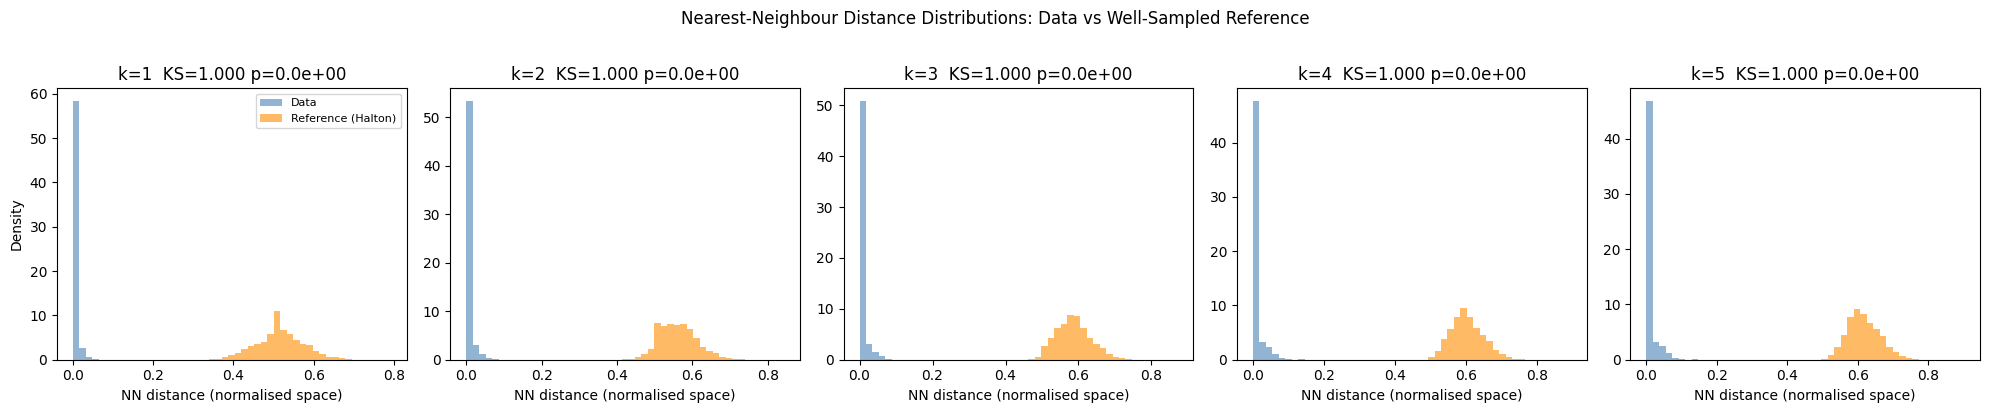

In [12]:
# ── 2. Histogram: NN distance distributions ──────────────────────────────────
fig, axes = plt.subplots(1, k, figsize=(4*k, 4), sharey=False)

for i, ax in enumerate(axes):
    bins = np.linspace(0, max(d_data[:, i].max(), d_ref[:, i].max()) * 1.05, 50)
    ax.hist(d_data[:, i], bins=bins, alpha=0.6, color='steelblue',
            density=True, label='Data')
    ax.hist(d_ref[:, i],  bins=bins, alpha=0.6, color='darkorange',
            density=True, label='Reference (Halton)')
    ks, p = ks_2samp(d_data[:, i], d_ref[:, i])
    ax.set_title(f'k={i+1}  KS={ks:.3f} p={p:.1e}')
    ax.set_xlabel('NN distance (normalised space)')
    if i == 0:
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)

plt.suptitle('Nearest-Neighbour Distance Distributions: Data vs Well-Sampled Reference',
             y=1.02)
plt.tight_layout()
plt.show()

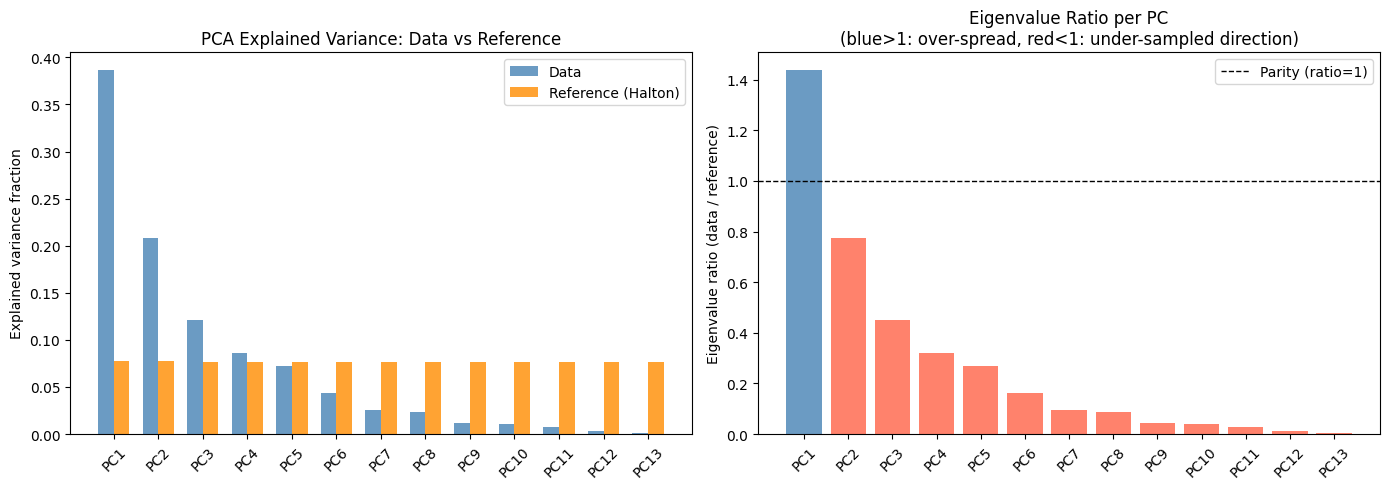


Eigenvalue ratios (data / reference) per PC:
  PC 1: 1.437  [over-spread]
  PC 2: 0.775  [under-sampled]
  PC 3: 0.451  [under-sampled]
  PC 4: 0.320  [under-sampled]
  PC 5: 0.268  [under-sampled]
  PC 6: 0.162  [under-sampled]
  PC 7: 0.094  [under-sampled]
  PC 8: 0.087  [under-sampled]
  PC 9: 0.045  [under-sampled]
  PC10: 0.041  [under-sampled]
  PC11: 0.029  [under-sampled]
  PC12: 0.011  [under-sampled]
  PC13: 0.004  [under-sampled]


In [13]:
# ── 3. PCA eigenvalue ratios ──────────────────────────────────────────────────
# For a perfectly uniform distribution in [0,1]^d, all eigenvalues should be
# equal (≈ 1/12 per dimension for uniform).  Deviations reveal over/under-
# sampled directions.

pca_data = PCA().fit(X)
pca_ref  = PCA().fit(X_ref)

ev_data = pca_data.explained_variance_
ev_ref  = pca_ref.explained_variance_

# Ratio: data eigenvalue / reference eigenvalue (>1 = over-spread, <1 = under-spread)
ratio = ev_data / ev_ref

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x = np.arange(d)
w = 0.35
ax.bar(x - w/2, ev_data / ev_data.sum(), w, label='Data', color='steelblue', alpha=0.8)
ax.bar(x + w/2, ev_ref  / ev_ref.sum(),  w, label='Reference (Halton)', color='darkorange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'PC{i+1}' for i in x], rotation=45)
ax.set_ylabel('Explained variance fraction')
ax.set_title('PCA Explained Variance: Data vs Reference')
ax.legend()

ax = axes[1]
colors = ['tomato' if r < 1 else 'steelblue' for r in ratio]
ax.bar(x, ratio, color=colors, alpha=0.8)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1, label='Parity (ratio=1)')
ax.set_xticks(x)
ax.set_xticklabels([f'PC{i+1}' for i in x], rotation=45)
ax.set_ylabel('Eigenvalue ratio (data / reference)')
ax.set_title('Eigenvalue Ratio per PC\n(blue>1: over-spread, red<1: under-sampled direction)')
ax.legend()

plt.tight_layout()
plt.show()

print("\nEigenvalue ratios (data / reference) per PC:")
for i, r in enumerate(ratio):
    tag = 'over-spread' if r > 1.2 else ('under-sampled' if r < 0.8 else 'similar')
    print(f"  PC{i+1:2d}: {r:.3f}  [{tag}]")

In [14]:
# ── 4. Per-parameter sampling uniformity (clustered vs well-spread) ──────────
# Histogram each normalized parameter into n_bins bins over [0,1].
# CV = std(bin_counts) / mean(bin_counts):
#   high CV → counts vary a lot across bins → data is clustered in some region
#   low CV  → counts are even → data is well spread

n_bins = 10
param_score = np.array([
    np.std(np.histogram(X_norm[:, i], bins=n_bins, range=(0, 1))[0]) / (len(X_norm) / n_bins)
    for i in range(d)
])

threshold = 0.5
fig, ax = plt.subplots(figsize=(max(10, d*0.8), 5))
colors = ['tomato' if s > threshold else 'steelblue' for s in param_score]
ax.bar(param_cols, param_score, color=colors, alpha=0.8)
ax.axhline(threshold, color='black', linestyle='--', linewidth=1)
ax.set_xticklabels(param_cols, rotation=45, ha='right')
ax.set_ylabel('Bin count CV  (std / mean)')
ax.set_title('Per-Parameter Sampling Uniformity\n'
             '(red > 0.5: clustered/over-sampled region;  blue ≤ 0.5: well spread)')
plt.tight_layout()
plt.show()

print('\nPer-parameter sampling uniformity (bin count CV):')
for name, s in sorted(zip(param_cols, param_score), key=lambda x: -x[1]):
    tag = 'clustered' if s > threshold else 'well-spread'
    print(f'  {name:<25s} {s:.3f}  [{tag}]')


NameError: name 'X_norm' is not defined

## PCA Component Heatmap

Each PC is a weighted combination of the original parameters.  
The heatmap below shows **which parameters load onto which PCs** (squared loadings, so values sum to 1 per PC).

### How to interpret the PCA results

| Quantity | What it means |
|---|---|
| **Eigenvalue ratio > 1** (blue bar) | Data is *more spread* in that PC direction than a well-sampled reference → the data is **clustered / concentrated** along that axis |
| **Eigenvalue ratio < 1** (red bar) | Data is *less spread* in that PC direction → the data **under-samples** that axis |
| **Ratio ≈ 1** | Coverage in that direction is similar to the reference |

The reference (Halton quasi-random) represents **equal spacing across all coordinates**.  
For a perfectly uniform distribution in [0,1]^d, all PCA eigenvalues are equal (≈ 1/12 per dimension).  
Deviations from ratio=1 reveal which *directions in parameter space* are over- or under-sampled.

The **per-parameter attribution** (bar chart above) shows the marginal variance ratio (data / reference) for each parameter — it answers: *which original parameters are over- or under-sampled relative to a well-spaced reference?*

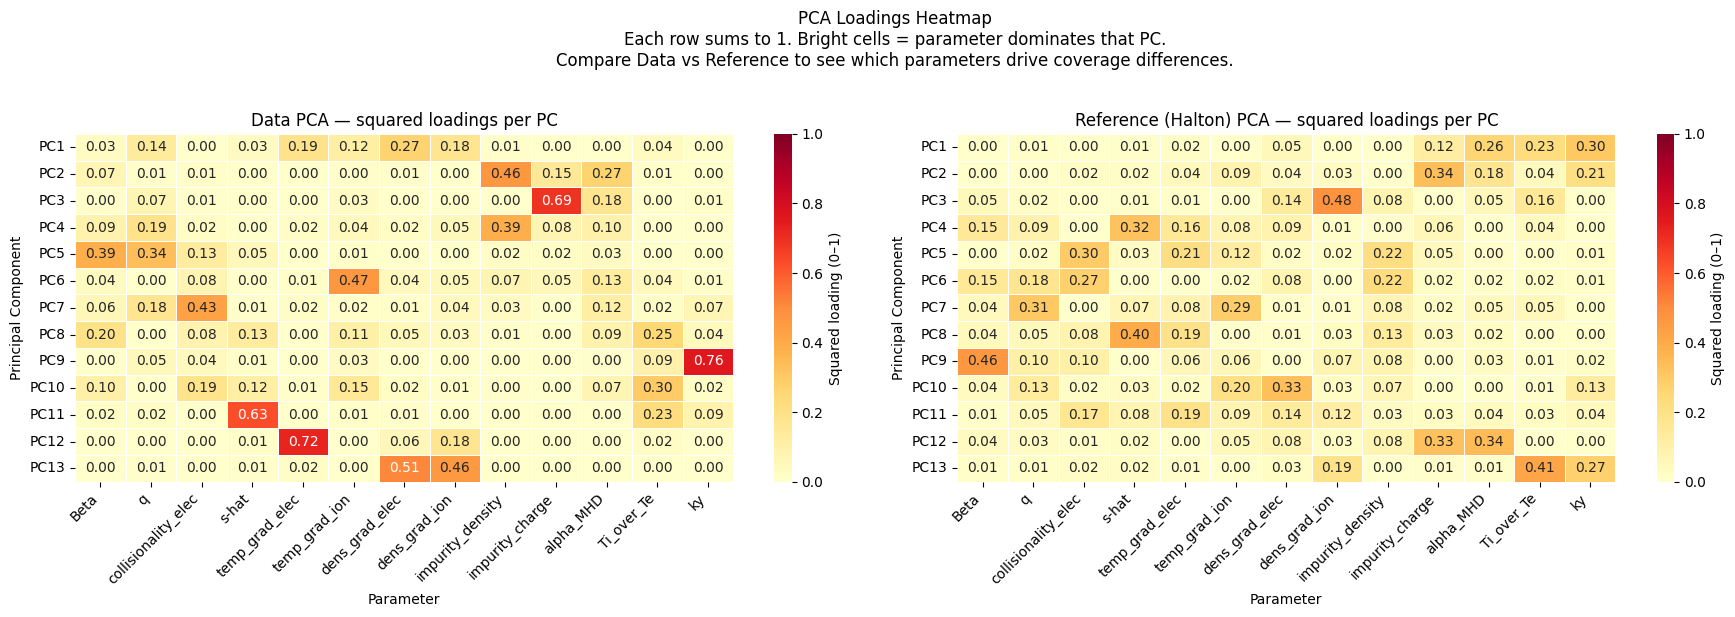

In [ ]:
# ── PCA loadings heatmap ──────────────────────────────────────────────────────
# Rows = PCs (sorted by explained variance, largest first)
# Columns = original parameters
# Cell value = squared loading (fraction of that PC's variance explained by each parameter)

import seaborn as sns

loadings_sq = pca_data.components_**2   # (d, d)  rows=PCs, cols=params

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, (mat, title) in zip(axes, [
        (loadings_sq,                    'Data PCA — squared loadings per PC'),
        (pca_ref.components_**2,         'Reference (Halton) PCA — squared loadings per PC'),
]):
    df_heat = pd.DataFrame(
        mat,
        index=[f'PC{i+1}' for i in range(d)],
        columns=param_cols
    )
    sns.heatmap(
        df_heat, ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
        annot=True, fmt='.2f', linewidths=0.4,
        cbar_kws={'label': 'Squared loading (0–1)'}
    )
    ax.set_title(title)
    ax.set_xlabel('Parameter')
    ax.set_ylabel('Principal Component')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.suptitle(
    'PCA Loadings Heatmap\n'
    'Each row sums to 1. Bright cells = parameter dominates that PC.\n'
    'Compare Data vs Reference to see which parameters drive coverage differences.',
    y=1.02
)
plt.tight_layout()
plt.show()

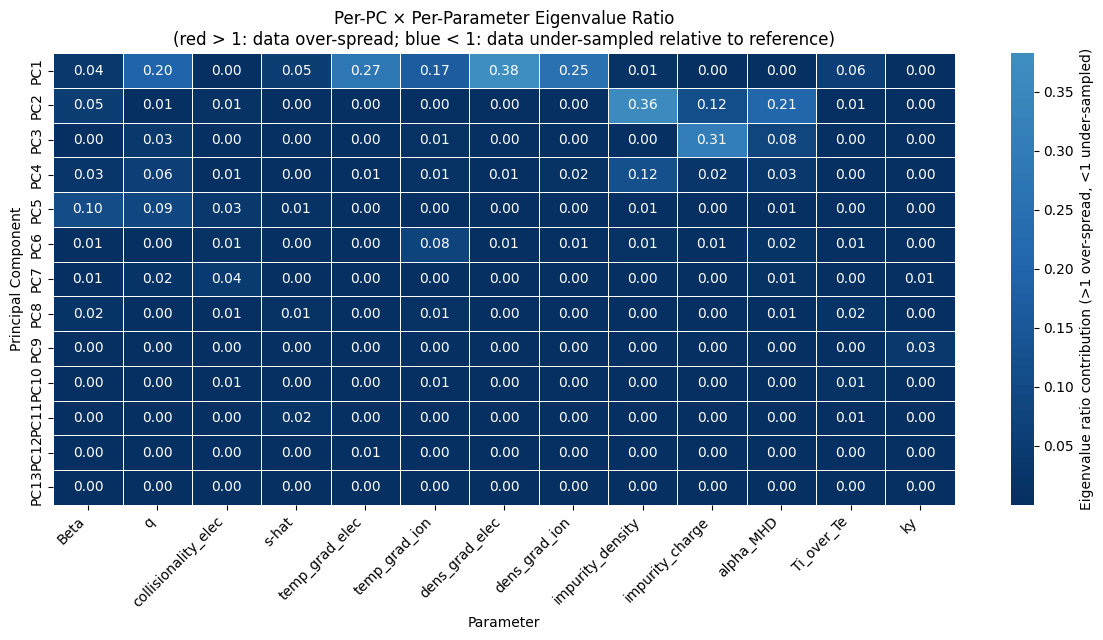


Column sums = per-parameter coverage score (same as bar chart above):
Beta                  0.263
q                     0.411
collisionality_elec   0.127
s-hat                 0.101
temp_grad_elec        0.297
temp_grad_ion         0.297
dens_grad_elec        0.412
dens_grad_ion         0.290
impurity_density      0.515
impurity_charge       0.468
alpha_MHD             0.371
Ti_over_Te            0.119
ky                    0.055


In [ ]:
# ── Eigenvalue ratio heatmap: data/reference per PC × parameter ───────────────
# For each PC, how much does each parameter contribute to the ratio?
# ratio_contribution[pc, param] = loadings_sq[pc, param] * ratio[pc]
# Values > 1 → that parameter/PC combination is over-spread in data vs reference

ratio_contrib = loadings_sq * ratio[:, None]   # (d, d)

df_ratio = pd.DataFrame(
    ratio_contrib,
    index=[f'PC{i+1}' for i in range(d)],
    columns=param_cols
)

fig, ax = plt.subplots(figsize=(max(12, d*0.9), max(6, d*0.5)))
sns.heatmap(
    df_ratio, ax=ax, cmap='RdBu_r', center=1.0,
    annot=True, fmt='.2f', linewidths=0.4,
    cbar_kws={'label': 'Eigenvalue ratio contribution (>1 over-spread, <1 under-sampled)'}
)
ax.set_title(
    'Per-PC × Per-Parameter Eigenvalue Ratio\n'
    '(red > 1: data over-spread; blue < 1: data under-sampled relative to reference)'
)
ax.set_xlabel('Parameter')
ax.set_ylabel('Principal Component')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nColumn sums = per-parameter coverage score (same as bar chart above):')
print(df_ratio.sum(axis=0).to_string(float_format='{:.3f}'.format))

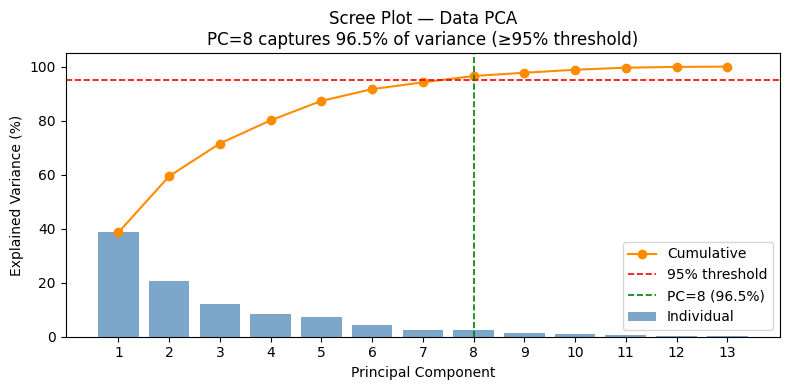


First 8 PCs capture 96.54% of data variance.


In [ ]:
# ── PCA Scree Plot: cumulative explained variance ─────────────────────────────
# Shows how many PCs are needed to capture ≥95% of the data variance.

ev_frac = pca_data.explained_variance_ratio_          # fraction per PC
cumvar  = np.cumsum(ev_frac)
n_pcs_95 = int(np.searchsorted(cumvar, 0.95)) + 1     # first PC where cumvar ≥ 95%

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, d + 1), ev_frac * 100, color='steelblue', alpha=0.7, label='Individual')
ax.plot(range(1, d + 1), cumvar * 100, 'o-', color='darkorange', label='Cumulative')
ax.axhline(95, color='red', linestyle='--', linewidth=1.2, label='95% threshold')
ax.axvline(n_pcs_95, color='green', linestyle='--', linewidth=1.2,
           label=f'PC={n_pcs_95} ({cumvar[n_pcs_95-1]*100:.1f}%)')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Scree Plot — Data PCA\n'
             f'PC={n_pcs_95} captures {cumvar[n_pcs_95-1]*100:.1f}% of variance (≥95% threshold)')
ax.set_xticks(range(1, d + 1))
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nFirst {n_pcs_95} PCs capture {cumvar[n_pcs_95-1]*100:.2f}% of data variance.')

/tmp/ipykernel_1091420/1603918238.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


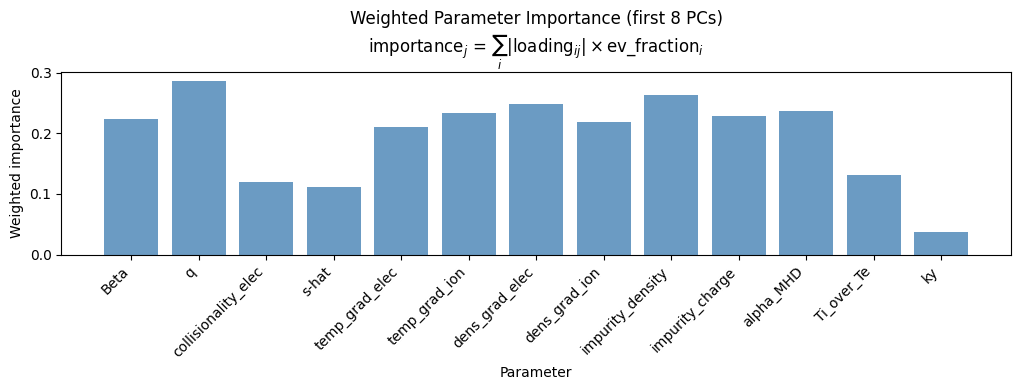


Weighted importance per parameter (first 8 PCs):
  q                         0.2866
  impurity_density          0.2622
  dens_grad_elec            0.2486
  alpha_MHD                 0.2369
  temp_grad_ion             0.2332
  impurity_charge           0.2289
  Beta                      0.2230
  dens_grad_ion             0.2180
  temp_grad_elec            0.2106
  Ti_over_Te                0.1304
  collisionality_elec       0.1198
  s-hat                     0.1115
  ky                        0.0369


In [ ]:
# ── Weighted Parameter Importance (first 8 PCs) ───────────────────────────────
# importance[j] = sum_i( |loading[i,j]| * ev_fraction[i] )  for i in 0..7
# Answers: which parameters drive the most variance in the first 8 PCs?

n_top = 8
ev_frac_top = pca_data.explained_variance_ratio_[:n_top]          # shape (8,)
loadings_top = pca_data.components_[:n_top, :]                    # shape (8, d)
importance = (np.abs(loadings_top) * ev_frac_top[:, None]).sum(axis=0)  # shape (d,)

fig, ax = plt.subplots(figsize=(max(10, d * 0.8), 4))
colors = ['steelblue'] * d
ax.bar(param_cols, importance, color=colors, alpha=0.8)
ax.set_xlabel('Parameter')
ax.set_ylabel('Weighted importance')
ax.set_title(
    f'Weighted Parameter Importance (first {n_top} PCs)\n'
    r'importance$_j$ = $\sum_i |\mathrm{loading}_{ij}| \times \mathrm{ev\_fraction}_i$'
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nWeighted importance per parameter (first 8 PCs):')
for name, imp in sorted(zip(param_cols, importance), key=lambda x: -x[1]):
    print(f'  {name:<25s} {imp:.4f}')

Mean pairwise distance — Data: 0.7039  |  Reference: 1.4393
  Ratio (data/ref): 0.489


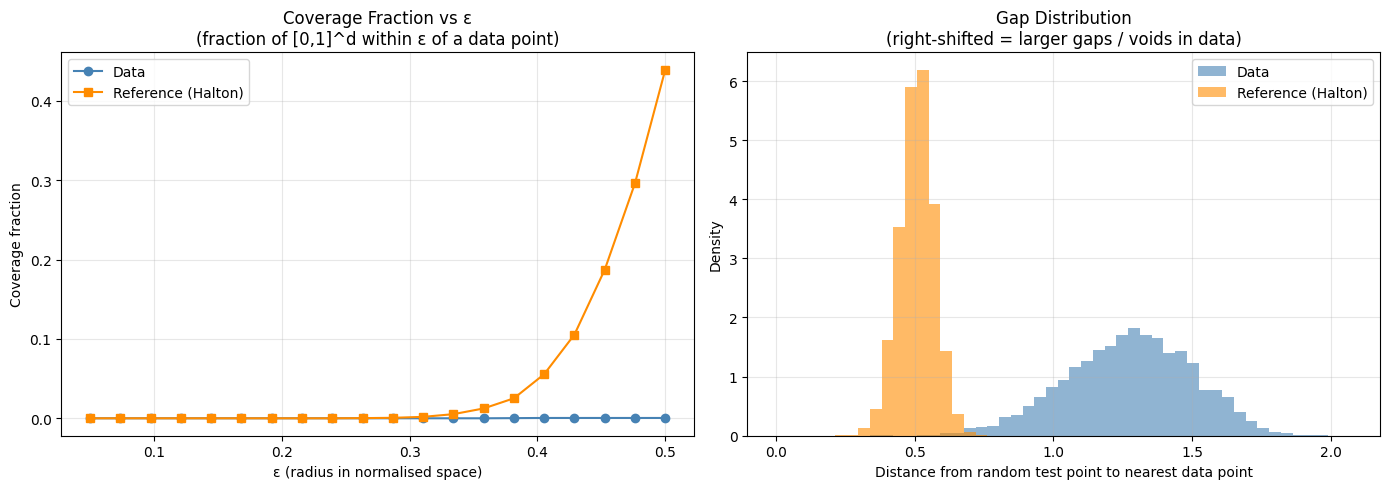


Gap distribution KS test: stat=0.9920, p=0.00e+00
Median gap — Data: 1.2808  |  Reference: 0.5088
95th-pct gap — Data: 1.6339  |  Reference: 0.6062


In [ ]:
# ── 5. General coverage metrics ───────────────────────────────────────────────

# 5a. Dispersion: mean pairwise distance (subsample for speed)
rng = np.random.default_rng(0)
idx = rng.choice(N, size=min(500, N), replace=False)
disp_data = cdist(X[idx], X[idx]).mean()
disp_ref  = cdist(X_ref[idx], X_ref[idx]).mean()
print(f"Mean pairwise distance — Data: {disp_data:.4f}  |  Reference: {disp_ref:.4f}")
print(f"  Ratio (data/ref): {disp_data/disp_ref:.3f}")

# 5b. Coverage fraction: fraction of [0,1]^d covered by ε-balls around data
# Estimated via Monte Carlo: what fraction of random test points have a data
# neighbour within ε?
eps_values = np.linspace(0.05, 0.5, 20)
M_test = 5000
X_test = rng.uniform(0, 1, size=(M_test, d))

nn_test_data = NearestNeighbors(n_neighbors=1).fit(X)
nn_test_ref  = NearestNeighbors(n_neighbors=1).fit(X_ref)
dist_test_data, _ = nn_test_data.kneighbors(X_test)
dist_test_ref,  _ = nn_test_ref.kneighbors(X_test)

cov_data = [(dist_test_data[:, 0] <= eps).mean() for eps in eps_values]
cov_ref  = [(dist_test_ref[:, 0]  <= eps).mean() for eps in eps_values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(eps_values, cov_data, 'o-', color='steelblue', label='Data')
ax.plot(eps_values, cov_ref,  's-', color='darkorange', label='Reference (Halton)')
ax.set_xlabel('ε (radius in normalised space)')
ax.set_ylabel('Coverage fraction')
ax.set_title('Coverage Fraction vs ε\n(fraction of [0,1]^d within ε of a data point)')
ax.legend()
ax.grid(True, alpha=0.3)

# 5c. Gap statistic: distribution of distances from test points to nearest data
ax = axes[1]
bins = np.linspace(0, max(dist_test_data.max(), dist_test_ref.max()) * 1.05, 50)
ax.hist(dist_test_data[:, 0], bins=bins, alpha=0.6, density=True,
        color='steelblue', label='Data')
ax.hist(dist_test_ref[:, 0],  bins=bins, alpha=0.6, density=True,
        color='darkorange', label='Reference (Halton)')
ax.set_xlabel('Distance from random test point to nearest data point')
ax.set_ylabel('Density')
ax.set_title('Gap Distribution\n(right-shifted = larger gaps / voids in data)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ks_gap, p_gap = ks_2samp(dist_test_data[:, 0], dist_test_ref[:, 0])
print(f"\nGap distribution KS test: stat={ks_gap:.4f}, p={p_gap:.2e}")
print(f"Median gap — Data: {np.median(dist_test_data):.4f}  |  Reference: {np.median(dist_test_ref):.4f}")
print(f"95th-pct gap — Data: {np.percentile(dist_test_data, 95):.4f}  |  Reference: {np.percentile(dist_test_ref, 95):.4f}")

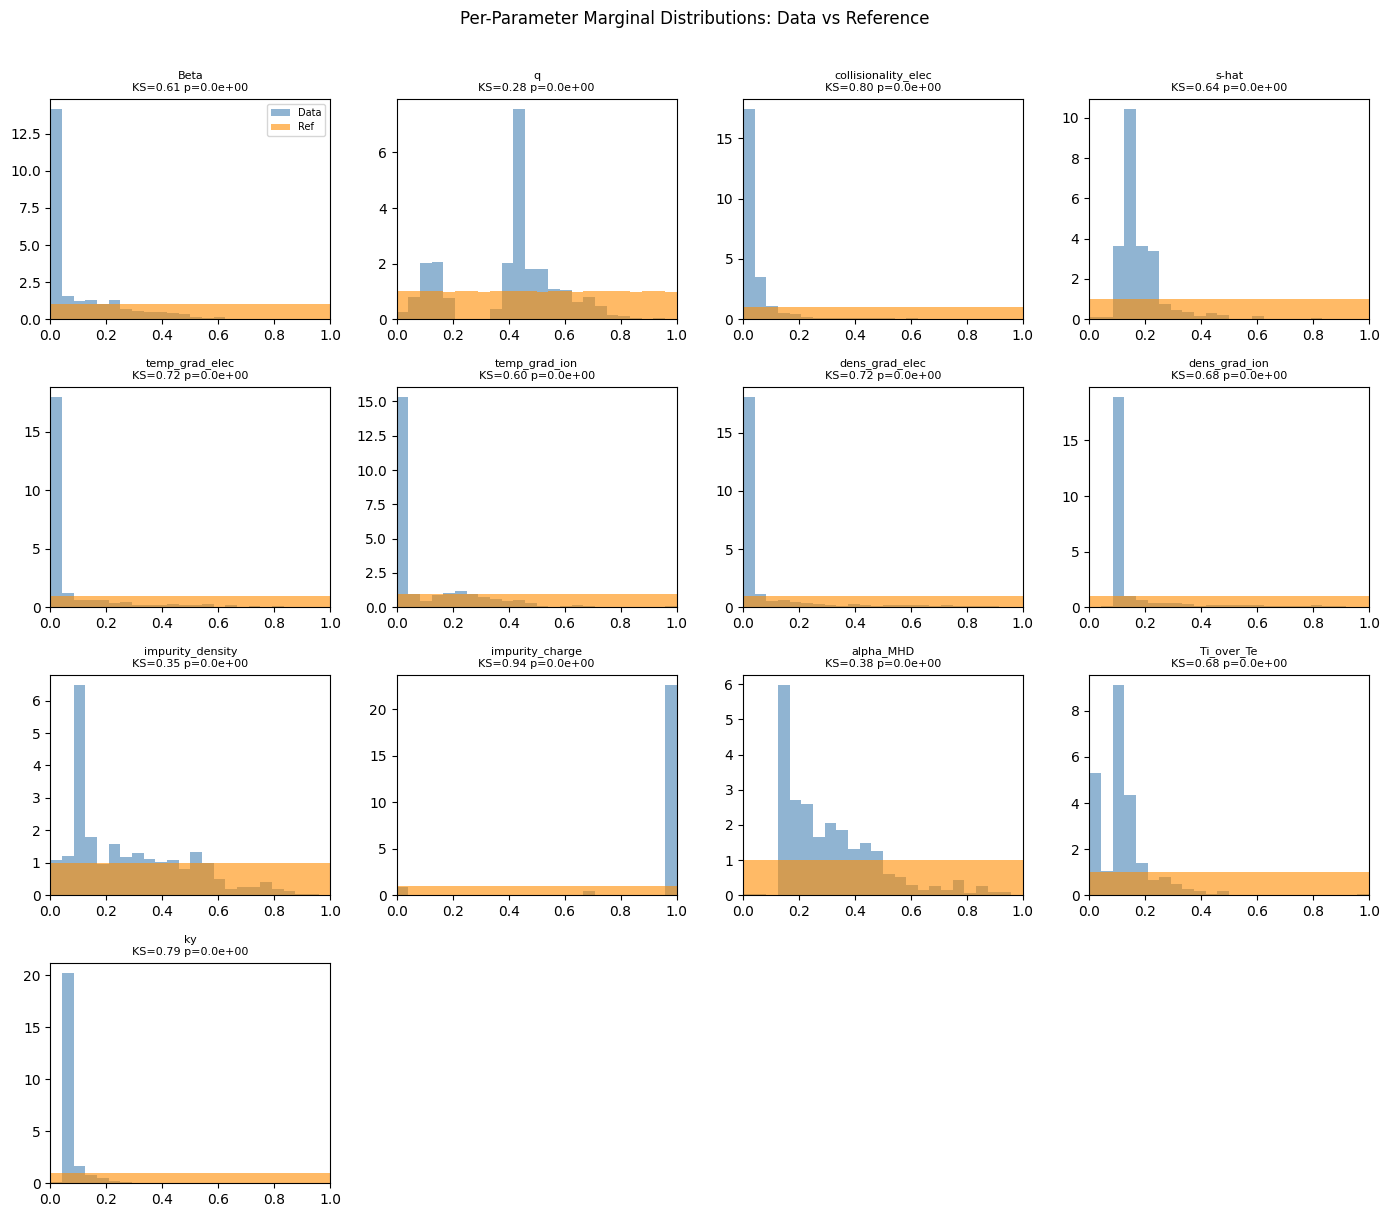

In [ ]:
# ── 6. Per-dimension marginal coverage ────────────────────────────────────────
# Compare 1D histograms of data vs reference for each parameter.

ncols = 4
nrows = int(np.ceil(d / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3.5, nrows*3))
axes = axes.flatten()

for j, name in enumerate(param_cols):
    ax = axes[j]
    bins = np.linspace(0, 1, 25)
    ax.hist(X[:, j],     bins=bins, alpha=0.6, density=True, color='steelblue', label='Data')
    ax.hist(X_ref[:, j], bins=bins, alpha=0.6, density=True, color='darkorange', label='Ref')
    ks, p = ks_2samp(X[:, j], X_ref[:, j])
    ax.set_title(f'{name}\nKS={ks:.2f} p={p:.1e}', fontsize=8)
    ax.set_xlim(0, 1)
    if j == 0:
        ax.legend(fontsize=7)

for j in range(d, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Per-Parameter Marginal Distributions: Data vs Reference', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ── 7. Summary table ──────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'parameter': param_cols,
    'data_mean': X.mean(axis=0),
    'data_std':  X.std(axis=0),
    'ref_mean':  X_ref.mean(axis=0),
    'ref_std':   X_ref.std(axis=0),
    'coverage_score': param_score,
})
summary['coverage_label'] = summary['coverage_score'].apply(
    lambda s: 'clustered' if s > 0.5 else 'well-spread'
)
print(summary.to_string(index=False, float_format='{:.3f}'.format))


          parameter  data_mean  data_std  ref_mean  ref_std  coverage_score coverage_label
               Beta      0.097     0.148     0.500    0.289           1.956      clustered
                  q      0.400     0.185     0.500    0.289           1.210      clustered
collisionality_elec      0.049     0.103     0.500    0.289           2.652      clustered
              s-hat      0.188     0.092     0.500    0.289           2.049      clustered
     temp_grad_elec      0.075     0.157     0.500    0.289           2.379      clustered
      temp_grad_ion      0.114     0.157     0.500    0.289           1.978      clustered
     dens_grad_elec      0.088     0.185     0.500    0.289           2.365      clustered
      dens_grad_ion      0.163     0.156     0.500    0.289           2.343      clustered
   impurity_density      0.279     0.207     0.500    0.289           0.982      clustered
    impurity_charge      0.954     0.198     0.500    0.289           2.803      clustered

# Plotting figures


Global coverage summary:
  Median gap — Data:   1.2820
  Median gap — Halton: 0.5109
  Mean gap   — Data:   1.2742
  Mean gap   — Halton: 0.5096

Local clustering summary:
  Mean 5-NN — Data:   0.005914
  Mean 5-NN — Halton: 0.576553
  Median 5-NN — Data:   0.001044
  Median 5-NN — Halton: 0.572391

Sampling priority summary:
impurity_charge        priority=0.2439  contribution=0.1301  undercoverage=0.9112  occupied=0.150
dens_grad_elec         priority=0.1424  contribution=0.1136  undercoverage=0.6096  occupied=1.000
dens_grad_ion          priority=0.1031  contribution=0.0795  undercoverage=0.6305  occupied=1.000
temp_grad_elec         priority=0.1027  contribution=0.0803  undercoverage=0.6219  occupied=1.000
temp_grad_ion          priority=0.0834  contribution=0.0802  undercoverage=0.5054  occupied=0.850
Beta                   priority=0.0706  contribution=0.0718  undercoverage=0.4783  occupied=0.950
q                      priority=0.0602  contribution=0.1135  undercoverage=0.2580  

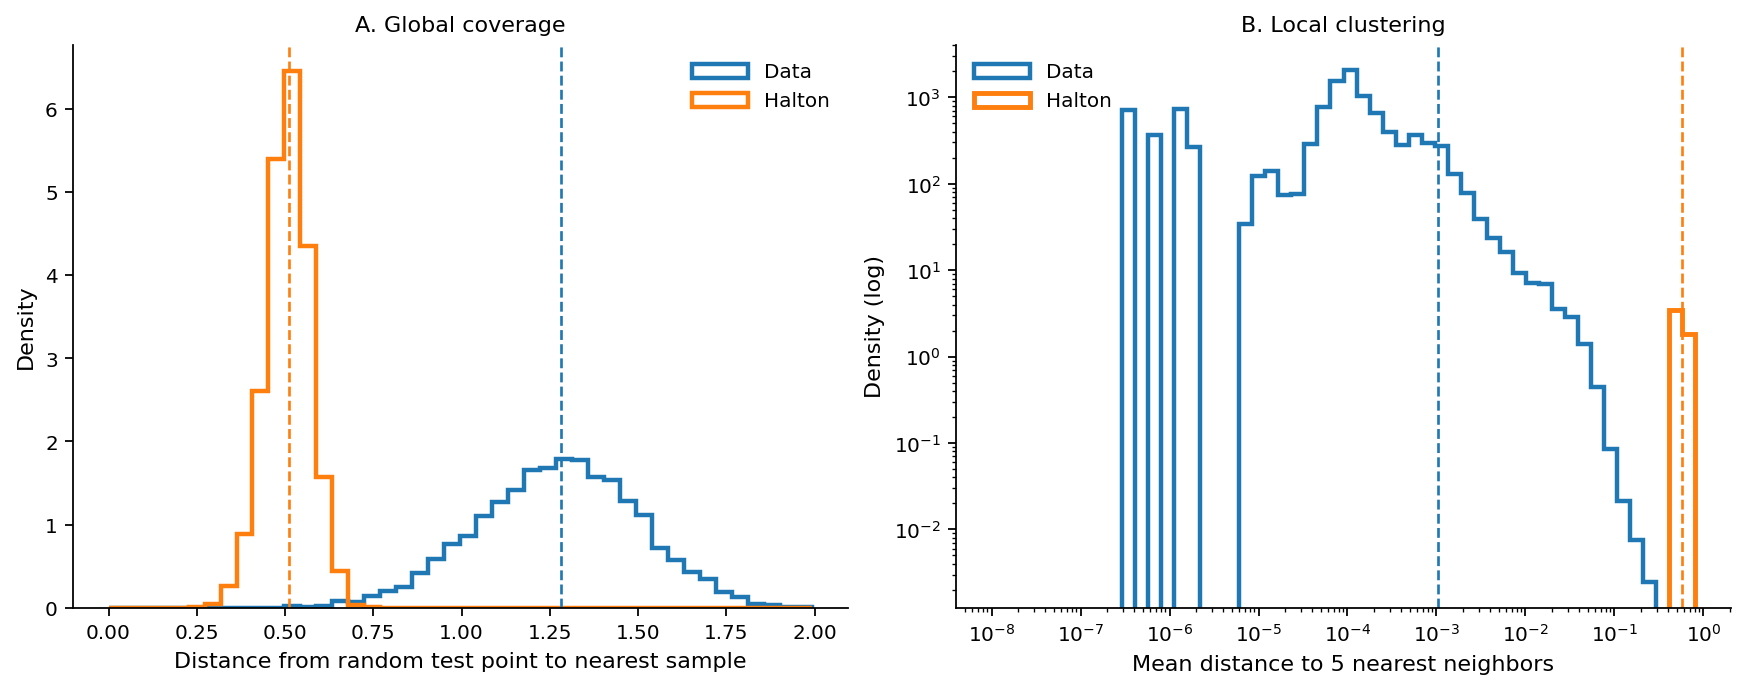

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# =============================================================================
# Publication style
# =============================================================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 160,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# =============================================================================
# Helpers
# =============================================================================
def knn_mean_distance(pts, k=5):
    nn = NearestNeighbors(n_neighbors=k + 1, algorithm="ball_tree").fit(pts)
    dists, _ = nn.kneighbors(pts)
    return dists[:, 1:].mean(axis=1)  # exclude self

def nearest_distance(query_pts, sample_pts):
    nn = NearestNeighbors(n_neighbors=1, algorithm="ball_tree").fit(sample_pts)
    dists, _ = nn.kneighbors(query_pts)
    return dists[:, 0]

# =============================================================================
# Compute global and local metrics
# =============================================================================
N, d = X.shape
k = 5

# --- Global coverage: 5000 random test points in [0,1]^d
rng = np.random.default_rng(0)
M_test = 5000
X_test = rng.uniform(0, 1, size=(M_test, d))

gap_data = nearest_distance(X_test, X)
gap_ref  = nearest_distance(X_test, X_ref)

# --- Local clustering: mean distance to k nearest neighbors
mean_d_data = knn_mean_distance(X, k=k)
mean_d_ref  = knn_mean_distance(X_ref, k=k)

# =============================================================================
# Priority score = PCA contribution × undercoverage
# =============================================================================
n_top = 8
n_bins = 20

ev_frac_top = pca_data.explained_variance_ratio_[:n_top]
loadings_top = pca_data.components_[:n_top, :]

# PCA contribution using squared loadings
contribution = ((loadings_top ** 2) * ev_frac_top[:, None]).sum(axis=0)
contribution = contribution / contribution.sum()

# Marginal undercoverage from normalized histogram entropy
entropy_norm = np.zeros(d)
occupied_frac = np.zeros(d)

for j in range(d):
    hist, _ = np.histogram(X[:, j], bins=n_bins, range=(0, 1))
    p = hist / hist.sum()
    p_nz = p[p > 0]
    entropy_norm[j] = -(p_nz * np.log(p_nz)).sum() / np.log(n_bins)
    occupied_frac[j] = (hist > 0).mean()

undercoverage = 1 - entropy_norm

priority = contribution * undercoverage
priority = priority / priority.sum()

order = np.argsort(priority)[::-1]
param_cols_sorted = [param_cols[i] for i in order]
priority_sorted = priority[order]
contribution_sorted = contribution[order]
undercoverage_sorted = undercoverage[order]

# =============================================================================
# Figure 1: Global + local histograms
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.2), constrained_layout=True)

# --- Panel A: global gap distribution
ax = axes[0]
bins_global = np.linspace(0, max(gap_data.max(), gap_ref.max()) * 1.02, 45)

ax.hist(
    gap_data,
    bins=bins_global,
    density=True,
    histtype="step",
    lw=2.0,
    color="#1f77b4",
    label="Data"
)
ax.hist(
    gap_ref,
    bins=bins_global,
    density=True,
    histtype="step",
    lw=2.0,
    color="#ff7f0e",
    label="Halton"
)

ax.axvline(np.median(gap_data), color="#1f77b4", ls="--", lw=1.2)
ax.axvline(np.median(gap_ref),  color="#ff7f0e", ls="--", lw=1.2)

ax.set_xlabel("Distance from random test point to nearest sample")
ax.set_ylabel("Density")
ax.set_title("A. Global coverage")
ax.legend(frameon=False, handlelength=2.8)

# --- Panel B: local clustering (log-log)
ax = axes[1]

positive_local = np.r_[mean_d_data[mean_d_data > 0], mean_d_ref[mean_d_ref > 0]]
xmin = max(positive_local.min(), 1e-8)
xmax = positive_local.max()
bins_local = np.logspace(np.log10(xmin), np.log10(xmax), 55)

ax.hist(
    mean_d_data,
    bins=bins_local,
    density=True,
    histtype="step",
    lw=2.0,
    color="#1f77b4",
    label="Data"
)
ax.hist(
    mean_d_ref,
    bins=bins_local,
    density=True,
    histtype="step",
    lw=2.2,
    color="#ff7f0e",
    label="Halton"
)

ax.axvline(np.median(mean_d_data), color="#1f77b4", ls="--", lw=1.2)
ax.axvline(np.median(mean_d_ref),  color="#ff7f0e", ls="--", lw=1.2)

ax.set_xscale("log")
ax.set_yscale("log")                          # ← this is the fix
ax.set_xlabel(f"Mean distance to {k} nearest neighbors")
ax.set_ylabel("Density (log)")
ax.set_title("B. Local clustering")
ax.legend(frameon=False, handlelength=2.8)

# =============================================================================
# Optional printed summary
# =============================================================================
print("\nGlobal coverage summary:")
print(f"  Median gap — Data:   {np.median(gap_data):.4f}")
print(f"  Median gap — Halton: {np.median(gap_ref):.4f}")
print(f"  Mean gap   — Data:   {gap_data.mean():.4f}")
print(f"  Mean gap   — Halton: {gap_ref.mean():.4f}")

print("\nLocal clustering summary:")
print(f"  Mean {k}-NN — Data:   {mean_d_data.mean():.6f}")
print(f"  Mean {k}-NN — Halton: {mean_d_ref.mean():.6f}")
print(f"  Median {k}-NN — Data:   {np.median(mean_d_data):.6f}")
print(f"  Median {k}-NN — Halton: {np.median(mean_d_ref):.6f}")

print("\nSampling priority summary:")
for i in order:
    print(
        f"{param_cols[i]:<22s} "
        f"priority={priority[i]:.4f}  "
        f"contribution={contribution[i]:.4f}  "
        f"undercoverage={undercoverage[i]:.4f}  "
        f"occupied={occupied_frac[i]:.3f}"
    )


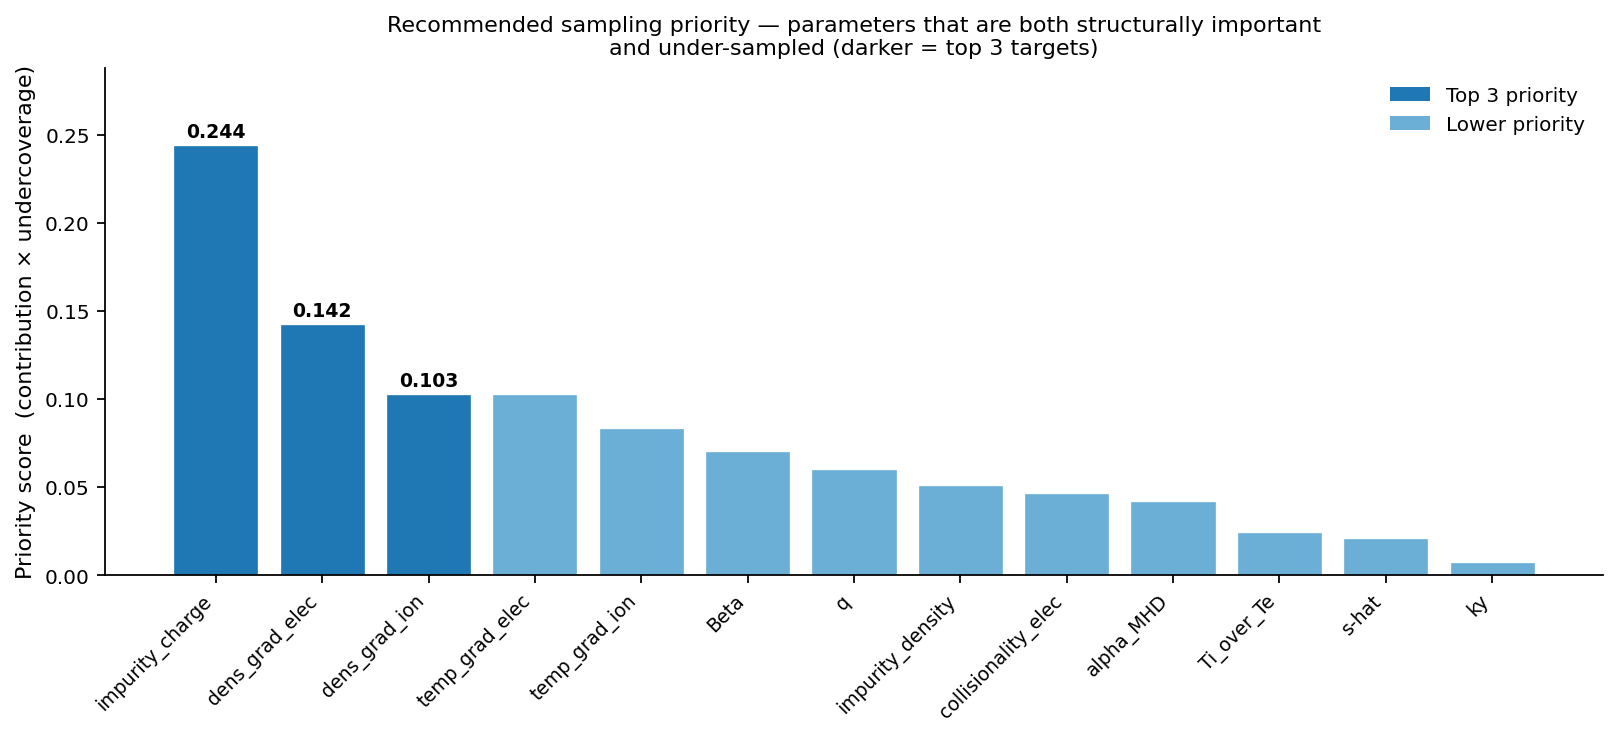

In [21]:
from matplotlib.patches import Patch

# ── Priority figure: standalone ───────────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)

bar_colors = ["#1f77b4" if i < 3 else "#6baed6" for i in range(len(param_cols_sorted))]
bars = ax.bar(param_cols_sorted, priority_sorted, color=bar_colors, edgecolor="white", linewidth=0.6)

# Dual-layer x-tick labels: parameter name + contribution/undercoverage breakdown
xtick_labels = [
    f"{p}"
    for p, _, _ in zip(param_cols_sorted, contribution_sorted, undercoverage_sorted)
]
ax.set_xticks(range(len(param_cols_sorted)))
ax.set_xticklabels(xtick_labels, rotation=45, ha="right", fontsize=8.5)

# Annotate top 3 bars with value
for i in range(3):
    ax.text(i, priority_sorted[i] + 0.002, f"{priority_sorted[i]:.3f}",
            ha="center", va="bottom", fontsize=8.5, fontweight="bold")

ax.set_ylabel("Priority score  (contribution × undercoverage)")
ax.set_title(
    "Recommended sampling priority — parameters that are both structurally important\n"
    "and under-sampled (darker = top 3 targets)",
    fontsize=10
)
ax.set_ylim(0, priority_sorted.max() * 1.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend_elements = [
    Patch(facecolor="#1f77b4", label="Top 3 priority"),
    Patch(facecolor="#6baed6", label="Lower priority"),
]
ax.legend(handles=legend_elements, frameon=False, loc="upper right", fontsize=9)

plt.show()